In [2]:
from google.colab import files
uploaded = files.upload()

Saving cardio_train.csv to cardio_train (1).csv


In [3]:
import csv
file_path = "cardio_train.csv"

data = []

with open(file_path, mode="r", newline="", encoding="utf-8") as file:
  reader = csv.DictReader(file, delimiter=";")

  for row in reader:
    row["id"] = int(row["id"])
    row["age"] = int(row["age"])
    row["gender"] = int(row["gender"])
    row["height"] = int(row["height"])
    row["weight"] = float(row["weight"])
    row["ap_hi"] = int(row["ap_hi"])
    row["ap_lo"] = int(row["ap_lo"])
    row["cholesterol"] = int(row["cholesterol"])
    row["gluc"] = int(row["gluc"])
    row["smoke"] = int(row["smoke"])
    row["alco"] = int(row["alco"])
    row["active"] = int(row["active"])
    row["cardio"] = int(row["cardio"])

    row["age_years"] = row["age"] / 365

    height_m = row["height"] / 100
    row["bmi"] = row["weight"] / (height_m ** 2)

    data.append(row)

print("Jumlah data:", len(data))
print("Contoh data pertama:")
print(data[0])

Jumlah data: 70000
Contoh data pertama:
{'id': 0, 'age': 18393, 'gender': 2, 'height': 168, 'weight': 62.0, 'ap_hi': 110, 'ap_lo': 80, 'cholesterol': 1, 'gluc': 1, 'smoke': 0, 'alco': 0, 'active': 1, 'cardio': 0, 'age_years': 50.391780821917806, 'bmi': 21.9671201814059}


In [4]:
clean_data = []
for row in data:
  if (80 <= row["ap_hi"] <= 240 and
      40 <= row["ap_lo"] <= 160 and
      row["ap_hi"] > row["ap_lo"] and
      120 <= row["height"] <= 220 and
      30 <= row["weight"] <= 200 and
      10 <= row["bmi"] <=60
      ):
    clean_data.append(row)

print("Jumlah data setelah dibersihkan:", len(clean_data))
print(clean_data[0])

Jumlah data setelah dibersihkan: 68585
{'id': 0, 'age': 18393, 'gender': 2, 'height': 168, 'weight': 62.0, 'ap_hi': 110, 'ap_lo': 80, 'cholesterol': 1, 'gluc': 1, 'smoke': 0, 'alco': 0, 'active': 1, 'cardio': 0, 'age_years': 50.391780821917806, 'bmi': 21.9671201814059}


In [5]:
# fungsi keanggotaan dasar
def turun(x, a, b):
  if x <= a:
    return 1
  elif x >= b:
    return 0
  else:
    return (b - x) / (b - a)

def naik(x, a, b):
  if x <= a:
    return 0
  elif x >= b:
    return 1
  else:
    return (x - a) / (b - a)

def segitiga(x, a, b, c):
  if x <= a or x >= c:
    return 0
  elif x == b:
    return 1
  elif a < x < b:
    return (x - a) / (b - a)
  else:
    return (c - x) / (c - b)

In [6]:
# membership input
# umur =================================
def umur_muda(age):
  return turun(age, 35, 45)

def umur_dewasa(age):
  return segitiga(age, 35, 50, 65)

def umur_lansia(age):
  return naik(age, 55, 65)

# bmi =================================
def bmi_normal(bmi):
  return turun(bmi, 23, 27)

def bmi_overweight(bmi):
  return segitiga(bmi, 25, 30, 35)

def bmi_obesitas(bmi):
  return naik(bmi, 30, 40)

# tekanan darah sistolik / ap_hi ======
def sistolik_normal(ap_hi):
  return turun(ap_hi, 120, 140)

def sistolik_tinggi(ap_hi):
  return segitiga(ap_hi, 130, 150, 170)

def sistolik_sangat_tinggi(ap_hi):
  return naik(ap_hi, 160, 180)

#tekanan darah distolik / ap_lo =======
def diastolik_normal(ap_lo):
  return turun(ap_lo, 80, 90)

def diastolik_tinggi(ap_lo):
  return segitiga(ap_lo, 85, 100, 115)

def diastolik_sangat_tinggi(ap_lo):
  return naik(ap_lo, 105, 120)

# kolesterol ==========================
def kolesterol_normal(chol):
  if chol == 1:
    return 1
  return 0

def kolesterol_tinggi(chol):
  if chol == 2:
    return 1
  return 0.5 if chol == 3 else 0

def kolesterol_sangat_tinggi(chol):
  if chol == 3:
    return 1
  return 0

In [7]:
# membership output risiko mamdani
def risiko_rendah(x):
  return turun(x, 30, 50)

def risiko_sedang(x):
  return segitiga(x, 30, 55, 80)

def risiko_tinggi(x):
  return naik(x, 60, 80)

In [8]:
# RULE BASE GABUNGAN - Mamdani & Sugeno
def hitung_rules(row):
  age = row["age_years"]
  bmi = row["bmi"]
  ap_hi = row["ap_hi"]
  ap_lo = row["ap_lo"]
  chol = row["cholesterol"]

  rules = []

  rules.append({
      "kode": "R1",
      "deskripsi": "umur muda AND BMI normal AND sistolik normal AND diastolik normal AND kolesterol normal",
      "alpha": min(umur_muda(age), bmi_normal(bmi), sistolik_normal(ap_hi), diastolik_normal(ap_lo), kolesterol_normal(chol)),
      "mamdani": "rendah",
      "sugeno": 20
  })
  rules.append({
      "kode": "R2",
      "deskripsi": "umur muda AND BMI normal AND sistolik normal AND diastolik normal AND kolesterol tinggi",
      "alpha": min(umur_muda(age), bmi_normal(bmi), sistolik_normal(ap_hi), diastolik_normal(ap_lo), kolesterol_tinggi(chol)),
      "mamdani": "sedang",
      "sugeno": 45
  })
  rules.append({
      "kode": "R3",
      "deskripsi": "umur muda AND BMI overweight AND sistolik normal AND diastolik normal",
      "alpha": min(umur_muda(age), bmi_overweight(bmi), sistolik_normal(ap_hi), diastolik_normal(ap_lo)),
      "mamdani": "sedang",
      "sugeno": 45
  })
  rules.append({
      "kode": "R4",
      "deskripsi": "umur muda AND BMI obesitas AND sistolik tinggi AND diastolik tinggi",
      "alpha": min(umur_muda(age), bmi_obesitas(bmi), sistolik_tinggi(ap_hi), diastolik_tinggi(ap_lo)),
      "mamdani": "tinggi",
      "sugeno": 75
  })
  rules.append({
      "kode": "R5",
      "deskripsi": "umur dewasa AND BMI normal AND sistolik normal AND diastolik normal AND kolesterol normal",
      "alpha": min(umur_dewasa(age), bmi_normal(bmi), sistolik_normal(ap_hi), diastolik_normal(ap_lo), kolesterol_normal(chol)),
      "mamdani": "rendah",
      "sugeno": 30
  })
  rules.append({
      "kode": "R6",
      "deskripsi": "umur dewasa AND BMI overweight AND sistolik normal AND diastolik normal",
      "alpha": min(umur_dewasa(age), bmi_overweight(bmi), sistolik_normal(ap_hi), diastolik_normal(ap_lo)),
      "mamdani": "sedang",
      "sugeno": 50
  })
  rules.append({
      "kode": "R7",
      "deskripsi": "umur dewasa AND BMI overweight AND sistolik tinggi AND diastolik tinggi",
      "alpha": min(umur_dewasa(age), bmi_overweight(bmi), sistolik_tinggi(ap_hi), diastolik_tinggi(ap_lo)),
      "mamdani": "sedang",
      "sugeno": 60
  })
  rules.append({
      "kode": "R8",
      "deskripsi": "umur dewasa AND BMI obesitas AND sistolik tinggi AND diastolik tinggi",
      "alpha": min(umur_dewasa(age), bmi_obesitas(bmi), sistolik_tinggi(ap_hi), diastolik_tinggi(ap_lo)),
      "mamdani": "tinggi",
      "sugeno": 80
  })
  rules.append({
      "kode": "R9",
      "deskripsi": "umur dewasa AND kolesterol sangat tinggi AND sistolik normal AND diastolik normal",
      "alpha": min(umur_dewasa(age), kolesterol_sangat_tinggi(chol), sistolik_normal(ap_hi), diastolik_normal(ap_lo)),
      "mamdani": "sedang",
      "sugeno": 60
  })
  rules.append({
      "kode": "R10",
      "deskripsi": "umur dewasa AND kolesterol sangat tinggi AND sistolik tinggi AND diastolik tinggi",
      "alpha": min(umur_dewasa(age), kolesterol_sangat_tinggi(chol), sistolik_tinggi(ap_hi), diastolik_tinggi(ap_lo)),
      "mamdani": "tinggi",
      "sugeno": 85
  })
  rules.append({
      "kode": "R11",
      "deskripsi": "umur lansia AND BMI normal AND sistolik normal AND diastolik normal AND kolesterol normal",
      "alpha": min(umur_lansia(age), bmi_normal(bmi), sistolik_normal(ap_hi), diastolik_normal(ap_lo), kolesterol_normal(chol)),
      "mamdani": "sedang",
      "sugeno": 55
  })
  rules.append({
      "kode": "R12",
      "deskripsi": "umur lansia AND BMI overweight AND sistolik normal AND diastolik normal",
      "alpha": min(umur_lansia(age), bmi_overweight(bmi), sistolik_normal(ap_hi), diastolik_normal(ap_lo)),
      "mamdani": "sedang",
      "sugeno": 65
  })
  rules.append({
      "kode": "R13",
      "deskripsi": "umur lansia AND sistolik tinggi AND diastolik tinggi",
      "alpha": min(umur_lansia(age), sistolik_tinggi(ap_hi), diastolik_tinggi(ap_lo)),
      "mamdani": "tinggi",
      "sugeno": 80
  })
  rules.append({
      "kode": "R14",
      "deskripsi": "umur lansia AND sistolik sangat tinggi AND diastolik sangat tinggi",
      "alpha": min(umur_lansia(age), sistolik_sangat_tinggi(ap_hi), diastolik_sangat_tinggi(ap_lo)),
      "mamdani": "tinggi",
      "sugeno": 90
  })
  rules.append({
      "kode": "R15",
      "deskripsi": "kolesterol sangat tinggi AND sistolik sangat tinggi AND diastolik sangat tinggi",
      "alpha": min(kolesterol_sangat_tinggi(chol), sistolik_sangat_tinggi(ap_hi), diastolik_sangat_tinggi(ap_lo)),
      "mamdani": "tinggi",
      "sugeno": 95
  })
  rules.append({
      "kode": "R16",
      "deskripsi": "BMI obesitas AND kolesterol sangat tinggi",
      "alpha": min(bmi_obesitas(bmi), kolesterol_sangat_tinggi(chol)),
      "mamdani": "tinggi",
      "sugeno": 85
  })
  rules.append({
      "kode": "R17",
      "deskripsi": "umur lansia AND BMI obesitas",
      "alpha": min(umur_lansia(age), bmi_obesitas(bmi)),
      "mamdani": "tinggi",
      "sugeno": 88
  })
  rules.append({
      "kode": "R18",
      "deskripsi": "umur lansia AND kolesterol sangat tinggi",
      "alpha": min(umur_lansia(age), kolesterol_sangat_tinggi(chol)),
      "mamdani": "tinggi",
      "sugeno": 90
  })
  rules.append({
      "kode": "R19",
      "deskripsi": "sistolik tinggi AND diastolik tinggi AND kolesterol tinggi",
      "alpha": min(sistolik_tinggi(ap_hi), diastolik_tinggi(ap_lo), kolesterol_tinggi(chol)),
      "mamdani": "tinggi",
      "sugeno": 82
  })
  rules.append({
      "kode": "R20",
      "deskripsi": "umur lansia AND sistolik tinggi AND diastolik tinggi AND kolesterol tinggi",
      "alpha": min(umur_lansia(age), sistolik_tinggi(ap_hi), diastolik_tinggi(ap_lo), kolesterol_tinggi(chol)),
      "mamdani": "tinggi",
      "sugeno": 88
  })
  return rules

In [9]:
# fuzzy mamdani
def mamdani(row):
  rules = hitung_rules(row)

  pembilang = 0
  penyebut = 0

  # domain output risiko: 0-100
  for x in range(0, 101):
    nilai_agregasi = 0

    for rule in rules:
      alpha = rule["alpha"]
      kategori = rule["mamdani"]

      if kategori == "rendah":
        nilai_membership_output = risiko_rendah(x)
      elif kategori == "sedang":
        nilai_membership_output = risiko_sedang(x)
      elif kategori == "tinggi":
        nilai_membership_output = risiko_tinggi(x)
      else:
        nilai_membership_output = 0

      # implikasi mamdani menggunakan min
      nilai_implikasi = min(alpha, nilai_membership_output)

      # agregasi mamdani menggunakan max
      nilai_agregasi = max(nilai_agregasi, nilai_implikasi)

    pembilang += x * nilai_agregasi
    penyebut += nilai_agregasi

  if penyebut == 0:
    return 0
  return pembilang / penyebut

In [10]:
# fuzzy sugeno
def sugeno(row):
  rules = hitung_rules(row)

  pembilang = 0
  penyebut = 0

  for rule in rules:
    alpha = rule["alpha"]
    z = rule["sugeno"]

    pembilang += alpha * z
    penyebut += alpha

  if penyebut == 0:
    return 0
  return pembilang / penyebut

In [11]:
# kategori risiko
def kategori_risiko(nilai):
    if nilai < 40:
        return "Rendah"
    elif nilai < 70:
        return "Sedang"
    else:
        return "Tinggi"

def prediksi_cardio(nilai_risiko):
  if nilai_risiko >= 50:
    return 1
  else: return 0

In [12]:
# test hasil fuzzy
for i in range(5):
    row = clean_data[i]

    hasil_mamdani = mamdani(row)
    hasil_sugeno = sugeno(row)

    print("Data ke-", i + 1)
    print("Umur:", round(row["age_years"], 2))
    print("BMI:", round(row["bmi"], 2))
    print("Sistolik:", row["ap_hi"])
    print("Diastolik:", row["ap_lo"])
    print("Kolesterol:", row["cholesterol"])
    print("Label asli cardio:", row["cardio"])
    print("Hasil Mamdani:", round(hasil_mamdani, 2), "-", kategori_risiko(hasil_mamdani))
    print("Hasil Sugeno:", round(hasil_sugeno, 2), "-", kategori_risiko(hasil_sugeno))
    print("-" * 50)

Data ke- 1
Umur: 50.39
BMI: 21.97
Sistolik: 110
Diastolik: 80
Kolesterol: 1
Label asli cardio: 0
Hasil Mamdani: 20.27 - Rendah
Hasil Sugeno: 30.0 - Rendah
--------------------------------------------------
Data ke- 2
Umur: 55.42
BMI: 34.93
Sistolik: 140
Diastolik: 90
Kolesterol: 3
Label asli cardio: 1
Hasil Mamdani: 81.71 - Tinggi
Hasil Sugeno: 83.34 - Tinggi
--------------------------------------------------
Data ke- 3
Umur: 51.66
BMI: 23.51
Sistolik: 130
Diastolik: 70
Kolesterol: 3
Label asli cardio: 1
Hasil Mamdani: 55.0 - Sedang
Hasil Sugeno: 60.0 - Sedang
--------------------------------------------------
Data ke- 4
Umur: 48.28
BMI: 28.71
Sistolik: 150
Diastolik: 100
Kolesterol: 1
Label asli cardio: 1
Hasil Mamdani: 55.0 - Sedang
Hasil Sugeno: 60.0 - Sedang
--------------------------------------------------
Data ke- 5
Umur: 47.87
BMI: 23.01
Sistolik: 100
Diastolik: 60
Kolesterol: 1
Label asli cardio: 0
Hasil Mamdani: 20.75 - Rendah
Hasil Sugeno: 30.0 - Rendah
---------------------

In [13]:
benar_mamdani = 0
benar_sugeno = 0

jumlah_data = len(clean_data)

for row in clean_data:
  hasil_mamdani = mamdani(row)
  hasil_sugeno = sugeno(row)

  pred_mamdani = prediksi_cardio(hasil_mamdani)
  pred_sugeno = prediksi_cardio(hasil_sugeno)

  if pred_mamdani == row["cardio"]:
    benar_mamdani += 1

  if pred_sugeno == row["cardio"]:
    benar_sugeno += 1

akurasi_mamdani = benar_mamdani / jumlah_data * 100
akurasi_sugeno = benar_sugeno / jumlah_data * 100

print(f"Jumlah data evaluasi: {jumlah_data}")
print("Akurasi Mamdani:", round(akurasi_mamdani, 2), "%")
print("Akurasi Sugeno:", round(akurasi_sugeno, 2), "%")

Jumlah data evaluasi: 68585
Akurasi Mamdani: 61.02 %
Akurasi Sugeno: 63.38 %


In [14]:
row = clean_data[0]
rules = hitung_rules(row)

print("Data yang dicek:")
print("Umur:", round(row["age_years"], 2))
print("BMI:", round(row["bmi"], 2))
print("Sistolik:", row["ap_hi"])
print("Diastolik:", row["ap_lo"])
print("Kolesterol:", row["cholesterol"])
print()

print("Rule yang aktif:")
for rule in rules:
  if rule["alpha"] > 0:
    print(rule["kode"], "-", rule["deskripsi"])
    print("Alpha:", round(rule["alpha"], 3))
    print("Output Mamdani:", rule["mamdani"])
    print("Output Sugeno:", rule["sugeno"])
    print("-" * 50)

Data yang dicek:
Umur: 50.39
BMI: 21.97
Sistolik: 110
Diastolik: 80
Kolesterol: 1

Rule yang aktif:
R5 - umur dewasa AND BMI normal AND sistolik normal AND diastolik normal AND kolesterol normal
Alpha: 0.974
Output Mamdani: rendah
Output Sugeno: 30
--------------------------------------------------


In [15]:
# machine learning random forest
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

X = []
y = []

for row in clean_data:
  X.append([
      row["age_years"],
      row["bmi"],
      row["ap_hi"],
      row["ap_lo"],
      row["cholesterol"],
      row["gluc"],
      row["smoke"],
      row["alco"],
      row["active"]
  ])
  y.append(row["cardio"])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

akurasi_rf = accuracy_score(y_test, y_pred_rf) * 100

print("Akurasi Random Forest:", round(akurasi_rf, 2), "%")
print()
print("Classification Report:")
print(classification_report(y_test, y_pred_rf))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

Akurasi Random Forest: 70.64 %

Classification Report:
              precision    recall  f1-score   support

           0       0.71      0.72      0.71      6958
           1       0.71      0.69      0.70      6759

    accuracy                           0.71     13717
   macro avg       0.71      0.71      0.71     13717
weighted avg       0.71      0.71      0.71     13717

Confusion Matrix:
[[5010 1948]
 [2079 4680]]


In [16]:
# Model Deep Learning
import numpy as np

from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.optimizers import Adam

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled = np.array(X_train_scaled, dtype="float32")
X_test_scaled = np.array(X_test_scaled, dtype="float32")
y_train_array = np.array(y_train, dtype="float32")
y_test_array = np.array(y_test, dtype="float32")

dl_model = Sequential([
    Input(shape=(X_train_scaled.shape[1],)),
    Dense(32, activation="relu"),
    Dense(16, activation="relu"),
    Dense(1, activation="sigmoid")
])
dl_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

history = dl_model.fit(
    X_train_scaled,
    y_train_array,
    epochs=10,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

loss_dl, akurasi_dl = dl_model.evaluate(X_test_scaled, y_test_array, verbose=0)
akurasi_dl = akurasi_dl*100
print("Akurasi Deep Learning MLP:", round(akurasi_dl, 2), "%")

Epoch 1/10
1372/1372 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.7236 - loss: 0.5609 - val_accuracy: 0.7363 - val_loss: 0.5422
Epoch 2/10
1372/1372 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.7296 - loss: 0.5489 - val_accuracy: 0.7367 - val_loss: 0.5414
Epoch 3/10
1372/1372 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.7312 - loss: 0.5469 - val_accuracy: 0.7358 - val_loss: 0.5411
Epoch 4/10
1372/1372 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.7310 - loss: 0.5458 - val_accuracy: 0.7382 - val_loss: 0.5425
Epoch 5/10
1372/1372 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7324 - loss: 0.5454 - val_accuracy: 0.7379 - val_loss: 0.5408
Epoch 6/10
1372/1372 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.7319 - loss: 0.5445 - val_accuracy: 0.7365 - val_loss: 0.5402
Epoch 7/10
1372/1372 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.7321 - loss: 0.5441 - val_accuracy: 0.7390 - val_loss: 0.5411
Epoch 8/10
1372/1372 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.7326 - loss: 0.5436 - 

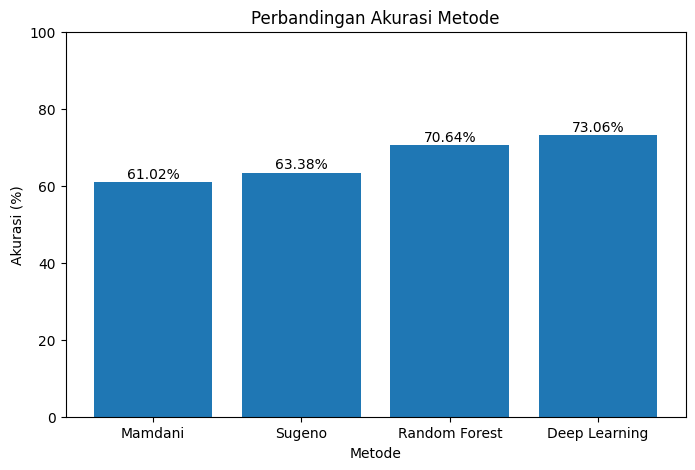

In [17]:
# Visualisasi
import matplotlib.pyplot as plt

metode = ["Mamdani", "Sugeno", "Random Forest", "Deep Learning"]
akurasi = [akurasi_mamdani, akurasi_sugeno, akurasi_rf, akurasi_dl]

plt.figure(figsize=(8, 5))
bars = plt.bar(metode, akurasi)
plt.title("Perbandingan Akurasi Metode")
plt.xlabel("Metode")
plt.ylabel("Akurasi (%)")
plt.ylim(0, 100)

for bar in bars:
  tinggi = bar.get_height()
  plt.text(
      bar.get_x() + bar.get_width() / 2,
      tinggi+1,
      f"{tinggi:.2f}%",
      ha="center"
  )

plt.show()